In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv('/content/2) Stock Prices Data Set.csv',
                 sep=None, engine='python', on_bad_lines='skip')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (497472, 7)

Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [2]:
# Use AAPL (Apple) as our stock for analysis
stock = df[df['symbol'] == 'AAPL'].copy()

# Convert date to datetime
stock['date'] = pd.to_datetime(stock['date'])
stock.set_index('date', inplace=True)
stock.sort_index(inplace=True)

print("AAPL data shape:", stock.shape)
print("Date range:", stock.index.min(), "to", stock.index.max())
stock[['close']].head()

AAPL data shape: (1007, 6)
Date range: 2014-01-02 00:00:00 to 2017-12-29 00:00:00


,close
date,
2014-01-02,79.0185
2014-01-03,77.2828
2014-01-06,77.7042
2014-01-07,77.1481
2014-01-08,77.6371


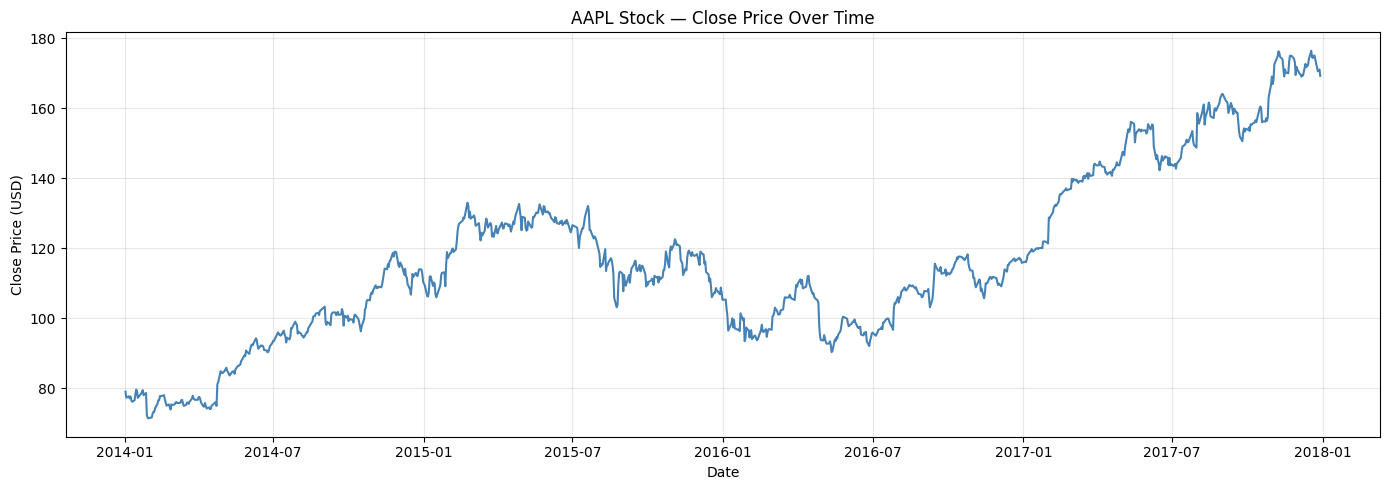

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(stock['close'], color='steelblue', linewidth=1.5)
plt.title('AAPL Stock — Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_price_over_time.png', dpi=150)
plt.show()

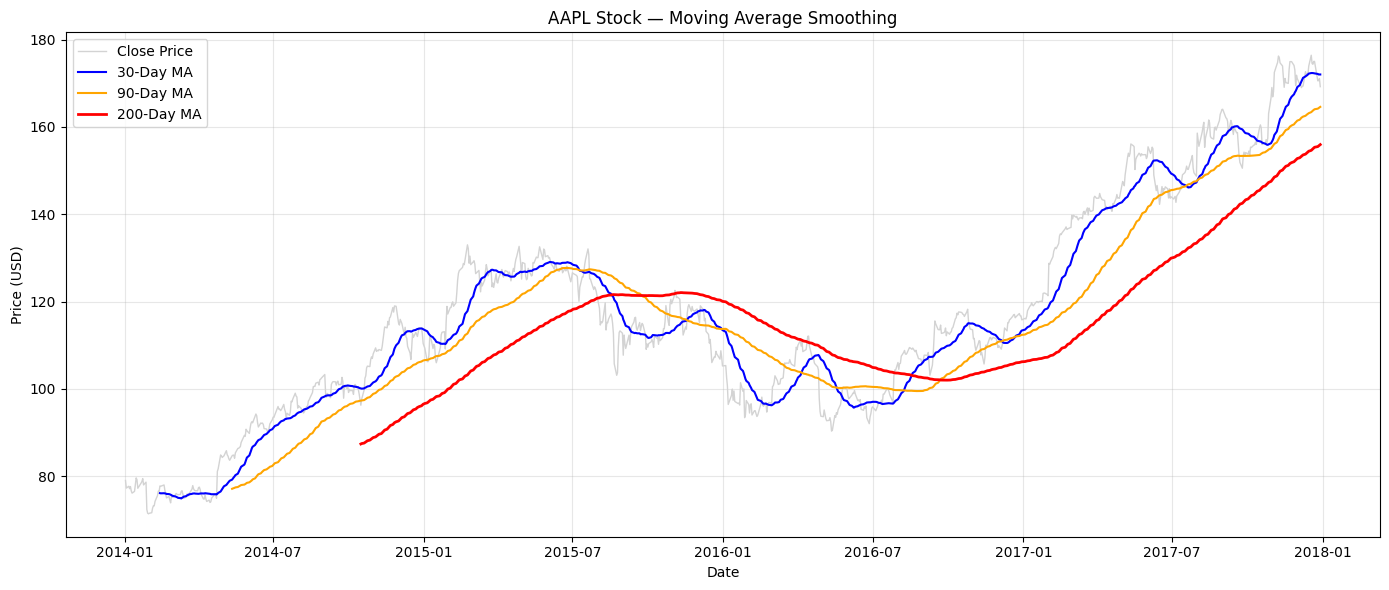

In [4]:
stock['MA_30']  = stock['close'].rolling(window=30).mean()
stock['MA_90']  = stock['close'].rolling(window=90).mean()
stock['MA_200'] = stock['close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(stock['close'],  color='lightgray',   linewidth=1,   label='Close Price')
plt.plot(stock['MA_30'],  color='blue',         linewidth=1.5, label='30-Day MA')
plt.plot(stock['MA_90'],  color='orange',       linewidth=1.5, label='90-Day MA')
plt.plot(stock['MA_200'], color='red',          linewidth=2,   label='200-Day MA')
plt.title('AAPL Stock — Moving Average Smoothing')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('moving_average.png', dpi=150)
plt.show()

/tmp/ipykernel_3637/2107770085.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = stock['close'].resample('M').mean()


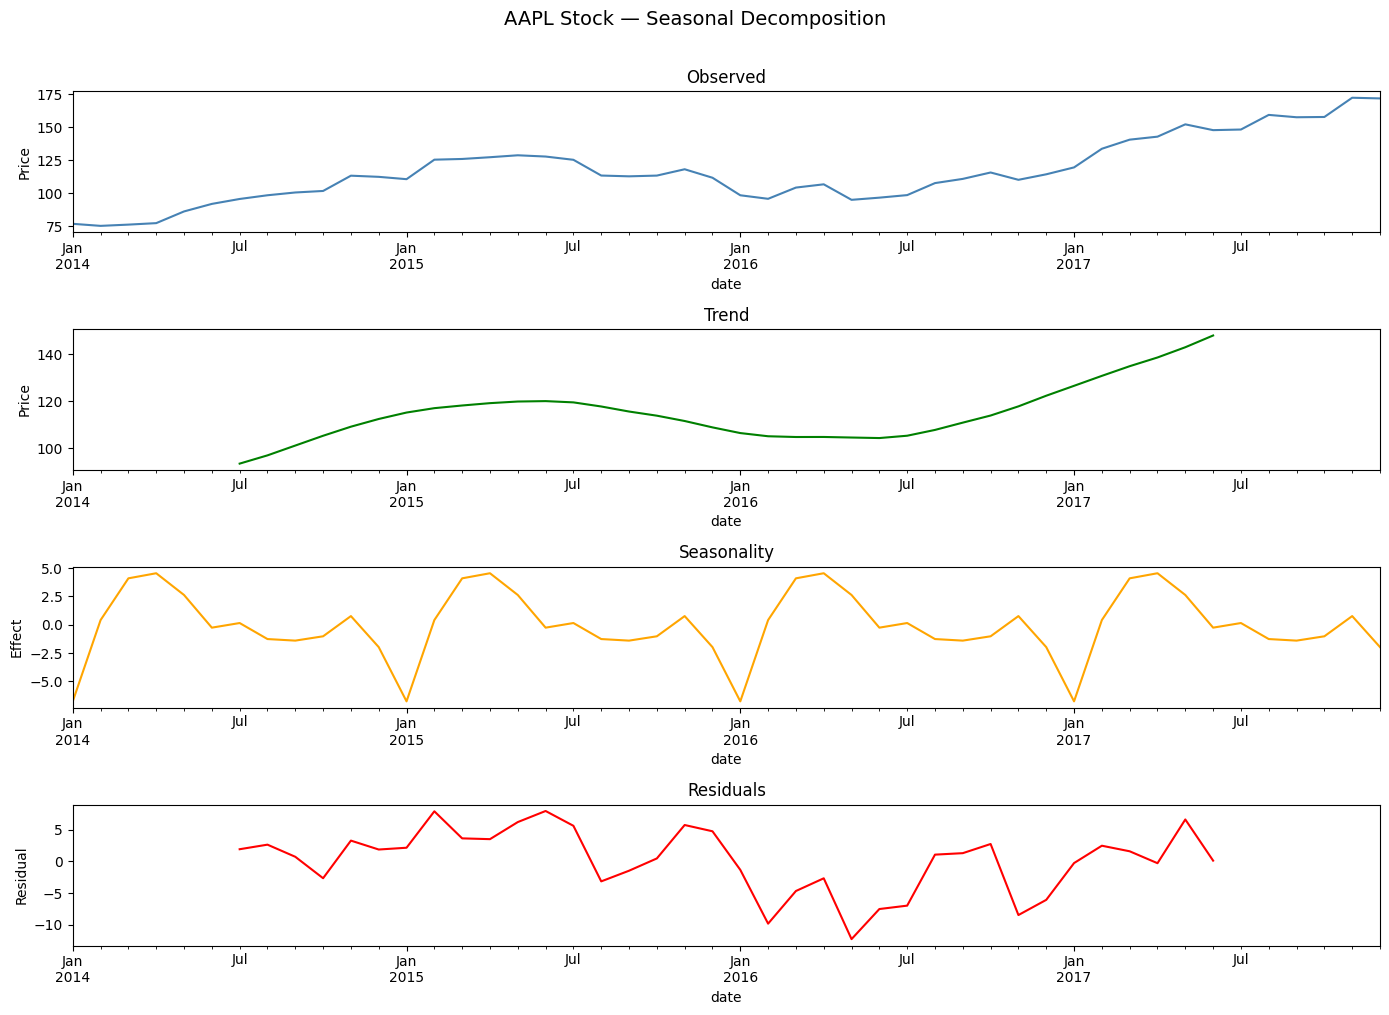

In [5]:
# Use monthly resampled data for decomposition
monthly = stock['close'].resample('M').mean()

decomposition = seasonal_decompose(monthly, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed')
axes[0].set_ylabel('Price')

decomposition.trend.plot(ax=axes[1], color='green')
axes[1].set_title('Trend')
axes[1].set_ylabel('Price')

decomposition.seasonal.plot(ax=axes[2], color='orange')
axes[2].set_title('Seasonality')
axes[2].set_ylabel('Effect')

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residuals')
axes[3].set_ylabel('Residual')

plt.suptitle('AAPL Stock — Seasonal Decomposition', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('seasonal_decomposition.png', dpi=150)
plt.show()

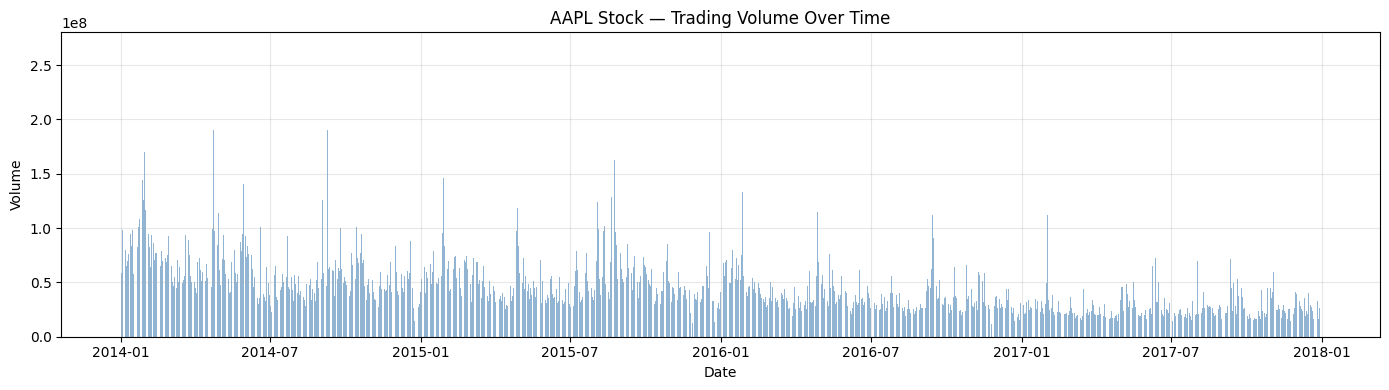

In [6]:
plt.figure(figsize=(14, 4))
plt.bar(stock.index, stock['volume'], color='steelblue', alpha=0.6, width=1)
plt.title('AAPL Stock — Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('volume_analysis.png', dpi=150)
plt.show()

In [7]:
from google.colab import files

files.download('stock_price_over_time.png')
files.download('moving_average.png')
files.download('seasonal_decomposition.png')
files.download('volume_analysis.png')
print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
